In [34]:
import pyproj
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
#np.random.seed(33)

## Genetic Algorithm - Πρόβλημα Περιοδεύοντος Πωλητή - Ομάδα 35

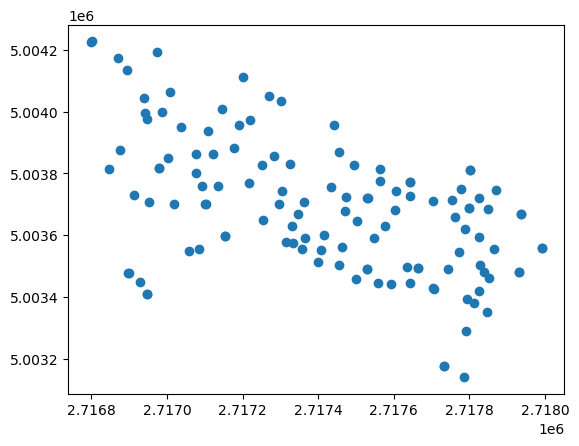

In [35]:
import pyproj
import xml.etree.ElementTree as ET

def parse_kml_file(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()

    coordinates = []
    for placemark in root.findall(".//{http://www.opengis.net/kml/2.2}Placemark"):
        coordinate_str = placemark.find(
            ".//{http://www.opengis.net/kml/2.2}coordinates"
        ).text.strip()
        coordinates.append(coordinate_str.split(","))

    return coordinates


def convert_coordinates(kml_file):
    coordinates = parse_kml_file(kml_file)

    # Set up the projection (e.g., Mercator)
    projection = pyproj.Proj('EPSG:3857')  # EPSG:3857 corresponds to Mercator

    converted_coordinates = []
    for coordinate in coordinates:
        lon, lat, alt = map(float, coordinate)  # Assuming coordinates are in (lon, lat, alt) format

        # Convert the coordinates
        x, y = projection(lon, lat)

        # Store the converted coordinates
        converted_coordinates.append((x, y))

    return converted_coordinates


kml_file = 'ERGASIA/Agios_Georgios.kml'
converted_coords = convert_coordinates(kml_file)
# print(converted_coords)

points = np.array(converted_coords)
plt.scatter(points[:,0],points[:,1]);

In [36]:
def eucl_dist(x,y):
    
    summation = 0
    
    for dim in np.arange(len(x)):
        summation += (x[dim] - y[dim])**2
    
    return np.sqrt(summation)

In [37]:
def path_length(array):
    
    length = 0
    
    for i in  np.arange(array.shape[0]-1):
        length += eucl_dist(array[i],array[i+1])
    
    return length

In [38]:
def bitswap(array):
    choices = np.random.choice(np.arange(array.shape[0]),2,replace=False)
    t1 = array[choices[0]]
    t2 = array[choices[1]]
    array = np.delete(array,choices[1])
    array = np.insert(array,choices[1],t1)
    array = np.delete(array,choices[0])
    array = np.insert(array,choices[0],t2)
    return array

bitswap(np.array([9,8,7,6,5,4,3,2,1,0]))

array([9, 5, 7, 6, 8, 4, 3, 2, 1, 0])

In [39]:
def initialize_population(pop_size=50, length_of_path=16):
    
    population = np.zeros((pop_size,length_of_path),dtype='int')
    
    for i in np.arange(pop_size):
        population[i] = np.random.choice(np.arange(length_of_path),length_of_path,replace=False)
        
    return population

In [40]:
initialize_population(3,3)

array([[0, 1, 2],
       [0, 2, 1],
       [1, 2, 0]])

In [41]:
def compute_paths_length(pop):
    
    num_of_paths = pop.shape[0]
    path_lengths = np.zeros(num_of_paths)
    
    for i in range(num_of_paths): 
        path_lengths[i] = path_length(points[pop[i]])
        
    return path_lengths

In [42]:
population = initialize_population(5,points.shape[0])
compute_paths_length(population)[:]

array([62431.90543546, 60364.33238883, 65008.38323616, 59314.56570991,
       61230.93173875])

In [43]:
def k_best_paths(k, pop, paths_length):
    
    indices =  np.argsort(paths_length)[:k]
    
    return pop[indices].copy(), paths_length[indices].copy()

In [44]:
lengths = compute_paths_length(population)
elites, elite_lengths = k_best_paths(2,population,lengths)
elites[:], elite_lengths[:]

(array([[ 68,  59,  41,  39, 106,  16,   9,  82,   7,   2,  65,  97,   0,
          28,  70,  77,  67,  88,  75,  80,  83,   8,  63,  11,  98,  44,
         118,  46,  17, 123,  72,  66, 120,  69,  42, 100,  10, 116,  53,
          85,  93,  35,   1, 111,  57, 105,  22,  94,  78,  32,  51,  58,
          23,  81,  38,   5,  24, 112, 104,  54,  62,  30, 103,  14,  96,
         109,  31,  47,  84, 119,  29,  86,   4,  90, 117,  25,  36, 122,
          87,  61,  21,  37,  73, 108,  48,  79,  27,   3, 101,  60,  99,
          26,  55,  92,  71,  33, 121, 113,   6,  45, 115,  19,  95,  91,
         114,  52,  15,  20,  43,  50, 110,  74,  18,  13,  49,  34,  89,
         102, 107,  64,  40,  76,  56,  12],
        [103,  38, 107,  69,  51,  16,  27, 115,  73,  25,  81,  28,  49,
          46, 113,  78,  66,  33,  53, 100,  10,  58,  56,  31,  18,  13,
          42, 117, 105,  39, 123,  21,   3,  19,  94,   9,   1,   0,  26,
          75,  22,   5,  20,  86,  71,  14,  44,  23,  37,  40,  87

In [45]:
def crossover(parents,num_children):
    
    children = np.zeros((num_children,parents.shape[1]),dtype='int')
    
    # for every new path (child)...
    for i in np.arange(num_children):
        
        # choose randomly two parents
        parent_inds = np.random.choice(parents.shape[0],2,replace=False)
        
        parent1_list = list(parents[parent_inds[0]])
        parent2 = parents[parent_inds[1]]   
        
        # choose randomly one point for the crossover (this splits the second parent into two parts)
        rand_point = np.random.choice(parent2.shape[0])
        
        # remove the digits of the first part (of the second parent) from the the first parent
        # and add and the end of the first parent the first part of the second parent
        for digit in parent2[rand_point:]: 
            parent1_list.remove(digit)
            parent1_list.append(digit)
        
        children[i] = np.array(parent1_list)
        
    return children

In [46]:
expe = np.array([[0,1,2,3,4,5,6,7],
                 [1,0,3,2,5,6,7,4]])
crossover(expe,10)

array([[1, 0, 2, 3, 4, 5, 6, 7],
       [1, 0, 3, 2, 4, 5, 6, 7],
       [0, 1, 2, 3, 4, 5, 6, 7],
       [1, 0, 3, 2, 4, 5, 6, 7],
       [0, 1, 3, 2, 5, 6, 7, 4],
       [1, 0, 3, 2, 4, 5, 6, 7],
       [0, 1, 2, 3, 5, 6, 7, 4],
       [1, 0, 3, 2, 5, 6, 7, 4],
       [0, 1, 2, 3, 5, 6, 7, 4],
       [1, 0, 3, 2, 5, 6, 7, 4]])

In [47]:
def mutation(paths,m):
    
    mutants = np.zeros((m,paths.shape[1]),dtype='int')
    
    for i in np.arange(m):
        # choose randomly one path
        choice = np.random.choice(paths.shape[0])
        # apply mutation via the bitswap operation
        mutants[i] = bitswap(paths[choice])
        
    return mutants

In [48]:
def next_generation_members(children, children_res, parents, parents_res, pop_size):
    
    # apply "μ+΄λ" logic
    candidates = np.vstack((children,parents))
    
    candidates_res = np.hstack((children_res,parents_res))
    
    pop, pop_res = k_best_paths(pop_size,candidates,candidates_res)
    
    return pop, pop_res

In [49]:
def genetic_algorithm(points,pop_size,num_elites,num_children,num_mutants,num_iter):

    # step 1: initialization of population
    pop = initialize_population(pop_size,points.shape[0])
    
    # store the best path
    pop_res = compute_paths_length(pop)
    best_path, best_path_length = k_best_paths(1, pop, pop_res)

    monitor=[]

    for i in tqdm(np.arange(num_iter)):
        
        # step 2: choose the k-best members of the population to become parents
        parents, parents_res = k_best_paths(num_elites,pop,pop_res)
        
        # step 3: crossover...
        children = crossover(parents,num_children)
        
        #... and mutation
        children  = mutation(children,num_mutants)
    
        # step 4: evaluate children
        children_res = compute_paths_length(children)
    
        # step 5: build new population using μ+΄λ algorithm
        pop, pop_res = next_generation_members(children,children_res,parents,parents_res,pop_size)
        
        # step 6: update best_path
        
        # find the best path of the current population
        best_current_path, best_current_path_length = k_best_paths(1, pop, pop_res)
        
        # update if it is better
        if best_path_length > best_current_path_length:
            best_path_length = best_current_path_length.copy()
            best_path = best_current_path.copy()
    
        # store the best at each iteration
        monitor.append(best_path_length)
    
    return best_path, best_path_length, monitor

In [54]:
best_path, best_path_length, monitor = genetic_algorithm(points,124,70,70,30,100000)

print(best_path_length)
print('')

100%|██████████| 100000/100000 [1:39:15<00:00, 16.79it/s]

[12456.39542338]



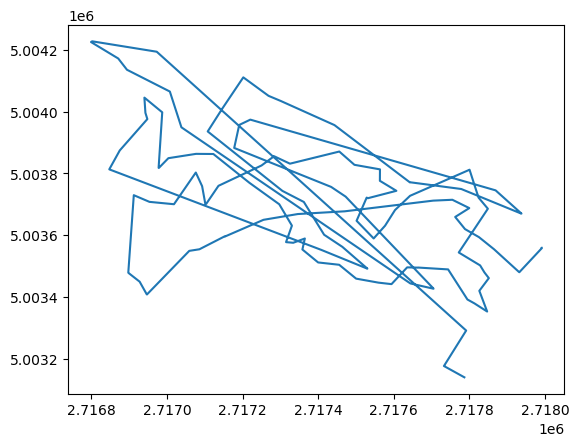

In [55]:
plt.plot(points[best_path[0],0],
         points[best_path[0],1]);